# Multi-Armed-Bandit with beta-bernoulli mechanics

### Model Definition

In [1]:
# using Pkg #UNCOMMENT IF PACKAGES NOT INSTALLED -> ALSO ADD [add IJulia] IF YOU WANT TO USE JUPYTERS BOOK
# Pkg.add("Gen") 
# Pkg.add("Plots")
# Pkg.add("Random")
# Pkg.add("Distributions")
using Gen, Plots, Random, Distributions, LinearAlgebra

# Model Definition for MAB
@gen function multi_armed_bandit_model(
    success_prior::Vector{Float64},
    fail_prior::Vector{Float64},
    n_pulls_per_arm::Vector{Int}
)
    n_arms = length(success_prior)
    theta = [@trace(Gen.beta(success_prior[i], fail_prior[i]), (:theta, i)) for i in 1:n_arms] # Calculate theta for arm
    
    for i in 1:n_arms
        @trace(binom(n_pulls_per_arm[i], theta[i]), (:obs, i)) # Observation for arm i and theta i
    end
    
    return theta
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Vector{Float64}, Vector{Float64}, Vector{Int64}], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing], Main.var"##multi_armed_bandit_model#230", Bool[0, 0, 0], false)

### Inference Techniques from Gen

In [2]:
# IMPORTANCE SAMPLING
function is_inference(model, args, observations, num_samples)
    (traces, log_weights, _) = Gen.importance_sampling(
        model,
        args,
        observations,
        num_samples
    )
    weights = exp.(log_weights)
    return traces, weights
end

# metropolis_hastings
function mh_inference(
    prior_success::Vector{Float64},
    prior_fail::Vector{Float64},
    n_pulls_per_arm::Vector{Int},
    observations::Gen.ChoiceMap,
    num_iters::Int;
    burn_in::Int=1000  # Discard first 1000 samples
)
    # Generate initial trace
    (trace, _) = Gen.generate(
        multi_armed_bandit_model,
        (prior_success, prior_fail, n_pulls_per_arm),
        observations
    )
    
    n_arms = length(prior_success)
    traces = Vector{Gen.Trace}()
    
    # Run MH updates and collect traces after burn-in
    for iter in 1:(num_iters + burn_in)
        # Update all theta parameters in sequence
        for arm in 1:n_arms
            selection = Gen.select((:theta, arm))
            (trace, _) = Gen.metropolis_hastings(trace, selection) # Assign new trace to old or accepted trace
        end
        
        # Store trace after burn-in period
        if iter > burn_in
            push!(traces, trace)
        end
    end
    
    return traces  # Return ALL post-burn-in traces
end

# # HMC
# function hmc_inference(model, args, observations, num_samples)
#     init_trace = Gen.generate(model, args, observations)
#     chain = []
#     for _ in 1:num_samples
#         (new_trace, _) = Gen.hmc(init_trace, Gen.select(:theta), epsilon=0.05, L=10)
#         push!(chain, new_trace)
#         init_trace = new_trace
#     end
#     return chain, ones(num_samples)
# end

mh_inference (generic function with 1 method)

### Custom Inference Technique


In [3]:
# # Sample from posterior that we can calculate using conjugate beta bernoulli
# function beta_bernoulli_conjugate_inference(
#     prior_success::Vector{Float64},
#     prior_fail::Vector{Float64},
#     n_pulls_per_arm::Vector{Int},
#     observations::Gen.ChoiceMap,
#     num_samples::Int
# )
#     n_arms = length(prior_success)
#     successes = [observations[(:obs, i)] for i in 1:n_arms]
    
#     # Calculate posterior parameters
#     post_alpha = prior_success .+ successes
#     post_beta = prior_fail .+ n_pulls_per_arm .- successes
    
#     # Generate samples as proper Gen traces
#     traces = Vector{Gen.Trace}()
#     model_args = (prior_success, prior_fail, n_pulls_per_arm)
    
#     for _ in 1:num_samples
#         # Create choices with sampled thetas and fixed observations
#         choices = Gen.choicemap()
#         for i in 1:n_arms
#             choices[(:theta, i)] = rand(Beta(post_alpha[i], post_beta[i]))
#         end
        
#         # Merge with observations
#         merged_choices = Gen.merge(choices, observations)
        
#         # Generate valid Gen trace
#         trace, _ = Gen.generate(
#             multi_armed_bandit_model,
#             model_args,
#             merged_choices
#         )
#         push!(traces, trace)
#     end
    
#     return traces
# end

function beta_bernoulli_conjugate_inference(
    prior_success::Union{Vector{Float64}, Float64},
    prior_fail::Union{Vector{Float64}, Float64},
    n_pulls::Union{Vector{Int}, Int},
    observations::Gen.ChoiceMap,
    num_samples::Int
)
    # Determine model type based on input types
    is_mab = prior_success isa Vector
    
    if is_mab
        # MAB Model Parameters
        n_arms = length(prior_success)
        successes = [observations[(:obs, i)] for i in 1:n_arms]
        model = multi_armed_bandit_model
        model_args = (prior_success, prior_fail, n_pulls)
    else
        # Beta-Bernoulli Model Parameters
        N = n_pulls
        successes = sum([observations[(:data, i)] for i in 1:N])
        model = beta_bernoulli_model
        model_args = (prior_success, prior_fail, N)
    end
    
    # Calculate posterior parameters
    post_alpha = is_mab ? prior_success .+ successes : prior_success + successes
    post_beta = is_mab ? prior_fail .+ n_pulls .- successes : prior_fail + (n_pulls - successes)
    
    # Generate samples as proper Gen traces
    traces = Vector{Gen.Trace}()
    
    for _ in 1:num_samples
        choices = Gen.choicemap()
        
        if is_mab
            # MAB: Create choices for each arm
            for i in 1:n_arms
                choices[(:theta, i)] = rand(Beta(post_alpha[i], post_beta[i]))
            end
        else
            # Single arm: Create single theta choice
            choices[:theta] = rand(Beta(post_alpha, post_beta))
        end
        
        # Merge with observations and generate trace
        merged_choices = Gen.merge(choices, observations)
        trace, _ = Gen.generate(model, model_args, merged_choices)
        push!(traces, trace)
    end
    
    return traces
end

beta_bernoulli_conjugate_inference (generic function with 1 method)

### Comparison function

In [4]:
function compare_convergence(
    sample_sizes,
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations;
    num_runs::Int = 10
)
    # Calculate analytical truth once
    n_arms = length(prior_success)
    successes = [observations[(:obs, i)] for i in 1:n_arms]
    true_post_alpha = prior_success .+ successes
    true_post_beta = prior_fail .+ n_pulls_per_arm .- successes
    true_means = true_post_alpha ./ (true_post_alpha .+ true_post_beta)

    results = Dict{Int, NamedTuple}()

    for n in sample_sizes
        # Initialize error accumulators
        is_errors = zeros(num_runs)
        conjugate_errors = zeros(num_runs)
        mh_errors = zeros(num_runs)

        # Run multiple trials
        for run in 1:num_runs
            # Importance Sampling
            is_traces, is_weights = is_inference(
                multi_armed_bandit_model,
                (prior_success, prior_fail, n_pulls_per_arm),
                observations,
                n
            )
            is_means = [sum([tr[(:theta, i)] * w for (tr, w) in zip(is_traces, is_weights)])/sum(is_weights) 
                        for i in 1:n_arms]
            is_errors[run] = norm(is_means - true_means)

            # Conjugate inference
            conjugate_traces = beta_bernoulli_conjugate_inference(
                prior_success,
                prior_fail,
                n_pulls_per_arm,
                observations,
                n
            )
            conjugate_means = [mean([Gen.get_choices(tr)[(:theta, i)] for tr in conjugate_traces]) 
                              for i in 1:n_arms]
            conjugate_errors[run] = norm(conjugate_means - true_means)

            # Metropolis-Hastings
            mh_traces = mh_inference(
                prior_success,
                prior_fail,
                n_pulls_per_arm,
                observations,
                n
            )
            mh_means = [mean([Gen.get_choices(tr)[(:theta, i)] for tr in mh_traces]) 
                       for i in 1:n_arms]
            mh_errors[run] = norm(mh_means - true_means)
        end

        # Store average errors
        results[n] = (
            is_error = mean(is_errors),
            is_std = std(is_errors),
            conjugate_error = mean(conjugate_errors),
            conjugate_std = std(conjugate_errors),
            mh_error = mean(mh_errors),
            mh_std = std(mh_errors)
        )
    end

    return results
end

# Plot function helper
function plot_convergence(results, sample_sizes)
    p = plot(xlabel="Sample Size(Log10)", ylabel="Mean Error", 
             xscale=:log10,
             title="Convergence Comparison", 
             legend=:topright, size=(800, 600))

    # Convert sample sizes to Float64 for log scale plotting
    x_vals = sample_sizes

    # Importance Sampling
    is_errors = [results[n].is_error for n in sample_sizes]
    plot!(p, x_vals, is_errors, label="Importance Sampling")

    # Conjugate
    conjugate_errors = [results[n].conjugate_error for n in sample_sizes]
    plot!(p, x_vals, conjugate_errors, label="Conjugate Posterior Sampling")

    # Metropolis-Hastings
    mh_errors = [results[n].mh_error for n in sample_sizes]
    plot!(p, x_vals, mh_errors, label="Metropolis-Hastings")

    return p
end

plot_convergence (generic function with 1 method)

### Inference on model

In [5]:
#Initialize all observations & parameters
n_pulls_per_arm = [10, 10]  # Each arm pulled 10 times
prior_success = [1.0, 1.0]  # alpha prior for both arms
prior_fail = [1.0, 1.0] # beta prior for both arms
n_arms = length(n_pulls_per_arm)
model_args = (prior_success, prior_fail, n_pulls_per_arm)
sample_sizes = [10, 100, 1000, 10000, 100000] # For comparison function

# Observed data: 1 success out of 10 for arm 1, 3 out of 10 for arm 2
observations = choicemap()
observations[(:obs, 1)] = 1  # Arm 1 successes
observations[(:obs, 2)] = 3  # Arm 2 successes

3

### Test runs

In [6]:
# Run importance sampling
traces, weights = is_inference(
    multi_armed_bandit_model,
    model_args,
    observations,
    10000
)
posterior_means_is = [
    sum([tr[(:theta, i)] * w for (tr, w) in zip(traces, weights)]) / sum(weights)
    for i in 1:n_arms
]
println("Importance Sampling Posterior means:")
for (i, mean) in enumerate(posterior_means_is)
    println("Arm $i: $(round(mean, digits=3))")
end

# Run conjugate posterior inference
traces_conjugate = beta_bernoulli_conjugate_inference(
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations,
    10_000
)
posterior_means_conjugate = [
    mean([Gen.get_choices(tr)[(:theta, i)] for tr in traces_conjugate])
    for i in 1:n_arms
]
println("Conjugate Posterior means:")
for (i, mean) in enumerate(posterior_means_conjugate)
    println("Arm $i: $(round(mean, digits=3))")
end

# Run MH inference
mh_traces = mh_inference(
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations,
    10_000  # Total iterations (10,000 + burn_in)
)
posterior_means_mh = [
    mean([Gen.get_choices(tr)[(:theta, i)] for tr in mh_traces])
    for i in 1:n_arms
]
println("Metropolis-Hastings Posterior means:")
for (i, mean) in enumerate(posterior_means_mh)
    println("Arm $i: $(round(mean, digits=3))")
end

Importance Sampling Posterior means:
Arm 1: 0.168
Arm 2: 0.333
Conjugate Posterior means:
Arm 1: 0.166
Arm 2: 0.33
Metropolis-Hastings Posterior means:
Arm 1: 0.165
Arm 2: 0.336


### Comparison of inference techniques

Convergence Comparison:
Sample Size: 10
  IS Error: 0.13985
  Conjugate Error: 0.04444
  MH Error: 0.09673

Sample Size: 100
  IS Error: 0.03448
  Conjugate Error: 0.01645
  MH Error: 0.02771

Sample Size: 1000
  IS Error: 0.00888
  Conjugate Error: 0.00491
  MH Error: 0.00866

Sample Size: 10000
  IS Error: 0.00311
  Conjugate Error: 0.00142
  MH Error: 0.00313

Sample Size: 100000
  IS Error: 0.00094
  Conjugate Error: 0.00051
  MH Error: 0.00079



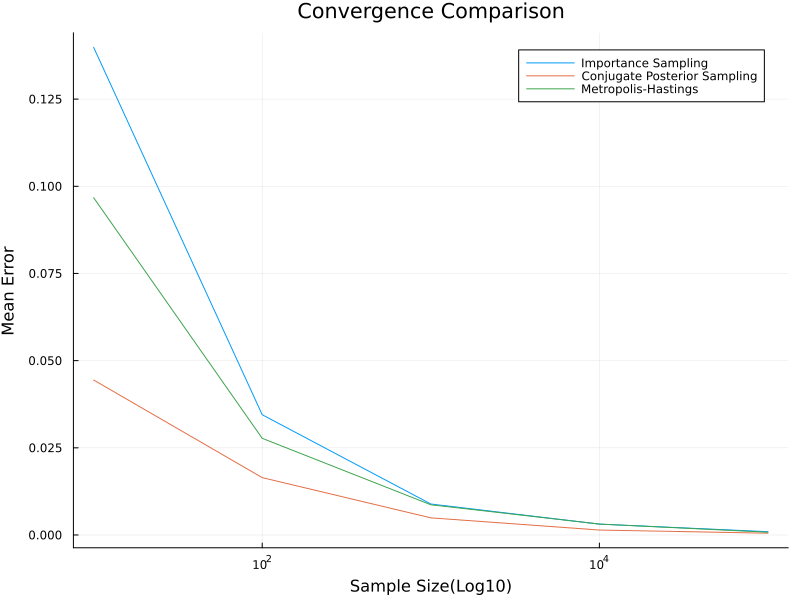

In [7]:
# Parameters passed through comparison function
results = compare_convergence(
    sample_sizes,  # Sample sizes to test
    prior_success,
    prior_fail,
    n_pulls_per_arm,
    observations,
    num_runs = 20  # Number of runs for each sample size
)

# Print results
println("Convergence Comparison:")
for (n, errs) in sort(collect(results))
    println("""
    Sample Size: $n
      IS Error: $(round(errs.is_error, digits=5))
      Conjugate Error: $(round(errs.conjugate_error, digits=5))
      MH Error: $(round(errs.mh_error, digits=5))
    """)
end

# Error convergence plot
p = plot_convergence(results, sample_sizes)
display(p)

## Inference on Beta-Bernoulli model using our custom Conjugate posterior sampler technique

In [8]:
# Model Definition for beta bernoulli
@gen function beta_bernoulli_model(α::Float64, β::Float64, N::Int)
    # θ ~ Beta(α, β)
    θ = @trace(beta(α, β), :theta)
    # Data points Dᵢ ~ Bernoulli(θ)
    for i in 1:N
        @trace(bernoulli(θ), (:data, i))
    end
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Float64, Float64, Int64], false, Union{Nothing, Some{Any}}[nothing, nothing, nothing], Main.var"##beta_bernoulli_model#232", Bool[0, 0, 0], false)

In [9]:
# Set observations
observations = choicemap()
data = [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]  # 7 successes, 3 failuress
for (i, outcome) in enumerate(data)
    observations[(:data, i)] = outcome
end

# Run conjugate inference
traces = beta_bernoulli_conjugate_inference(
    1.0,  # alpha prior
    1.0,  # beta prior
    10,    # Total trials
    observations,
    10000
)

# Calculate posterior mean from samples
theta_samples = [tr[:theta] for tr in traces]
sampled_mean = mean(theta_samples)

# Analytical solution
successes = sum(data)
analytical_mean = (1.0 + successes) / (1.0 + 1.0 + 10)

println("Sampled Posterior Mean: ", round(sampled_mean, digits=4))
println("Analytical Posterior Mean: ", round(analytical_mean, digits=4))

Sampled Posterior Mean: 0.6673
Analytical Posterior Mean: 0.6667
